# 07. Data Structures_Tree

앞서 선형 자료 구조 (Linear data structure)인 Array, Stack, Queue, Linked list에 대해 배웠습니다. 이제 남은 영역은 다음과 같고, 이번에는 Tree에 대해서 한 번 배워봅시다.

- Binary Tree: 각 Node가 두 개의 자식 Node를 가지는 트리 구조
- Red Black Tree: 색깔을 활용해 자체적으로 양 쪽 밸런스를 잡아주는 트리 구조
- Hashmaps: 키와 값을 가지는 자료 구조
- Tries: 단어의 저장과 검색을 빠르게 해주는 트리 구조
- Graphs: Edge로 이어진 Node의 모음

## 트리 (Tree)란?
- 트리 (Tree)는 이름에서 보다시피 나무와 같은 계층을 가지는 자료 구조입니다. 다만, `뿌리 노드 (root node)`가 최상단에 위치하고, `잎 노드 (leaf node)`가 최하단에 위치하는 형태로 구성됩니다.

<img src="imgsrc/BST_Example.png" alt="Binary Tree">

트리는 연결 리스트의 일종으로 각 노드가 `자식 노드 (child node)`에 대한 정보를 가지고 있습니다. 다만, 연결 리스트와는 다르게 하나의 노드가 여러개의 자식 노드를 가질 수 있습니다. 트리는 일반적으로 다음과 같은 규칙을 따르는 구조로 되어 있습니다.
- 각 노드는 자신의 값을 가집니다.
- 각 노드는 자식 노드를 가질 수 있습니다 (그렇지 않을 수도 있습니다).
- 각 노드는 하나의 부모 노드를 가질 수 있습니다 (뿌리 노드는 예외로 부모 노드가 없습니다).

$ 연결 리스트 (Linked List) $

``` python
node -> node -> node
```


$ 트리 (Tree) $

``` python
         > node
      > node
   > node
> node
         > node
      > node
         > node
      > node
   > node
      > node
```



## 이진 트리 (Binary Tree)란?
- 트리는 일반적으로 어떤 방법이든 정렬된 상태가 아니라면 유용하지 않습니다. 그리고 정렬된 트리 중 가장 유명한 것이 바로 이진 트리 (Binary Tree)입니다. 종종 자료 검색의 특성을 반영해, 이진 탐색 트리 (Binary Search Tree, BST)라고도 불립니다. BST는 다음과 같은 추가적인 규칙을 따르는 트리입니다.
    - 각 노드는 최대 두 개의 자식 노드를 가질 수 있습니다 (왼쪽 자식과 오른쪽 자식)
    - 왼쪽 자식 노등의 값은 항상 부모 노드의 값보다 작아야 합니다.
    - 오른쪽 자식 노드의 값은 항상 부모 노드의 값보다 커야 합니다.
    - 모든 노드는 고유한 값을 가져야 합니다 (중복된 값은 허용되지 않습니다).
- 챕터 03. Time_complexity의 예제 13에서 다뤘던 `병뚜껑에 적힌 숫자 맞추기`랑 비슷합니다.

## 예제37. 이진 트리 구현하기
- 이진 트리를 한 번 구현해봅시다. 위에 적힌 특성을 바탕으로 `BSTNode` 클래스의 `__init__` 메서드와 `insert` 메서드를 작성해보죠.
- `BSTNode` 클래스는 다음과 같은 속성을 가집니다.
    - `value`: 노드가 저장하는 값입니다. 이 예제에서는 `User` 객체가 될 것입니다. 또한 `User` 클래스에는 이미 구현된 연산자 메서드가 있어 `<`, `>`, `==` 연산을 사용할 수 있습니다.
    - `left`: 왼쪽 자식 노드를 가리키는 포인터입니다. 초기값은 `None`입니다. 입력에 따라 다른 BSTNode를 가리키게 됩니다.
    - `right`: 오른쪽 자식 노드를 가리키는 포인터입니다. 초기값은 `None`입니다. 입력에 따라 다른 BSTNode를 가리키게 됩니다.
- `insert` 메서드는 다음과 같은 로직으로 작동합니다.
    1. 만약 현재 노드에 값이 없다면, 입력된 값을 사용하고 끝냅니다.
    2. 만약 현재 노드의 값과 동일한 값이 입력되었다면, 중복은 허용하지 않기 때문에 아무 작업도 하지 않고 끝냅니다.
    3. 만약 현재 노드의 값보다 작은 값이 입력되었고, 현재 노드에 `left`가 없다면, 새로운 `left`를 생성하고 값을 할당한 후 끝냅니다.
    4. 만약 현재 노드의 값보다 작은 값이 입력되었고, 현재 노드에 `left`가 있다면, `left` 노드의 `insert` 메서드를 재귀적으로 호출하여 값을 삽입합니다.
    5. 현재 노드의 큰 값에 대해서는 `right` 노드에 대해서 동일하게 처리합니다.

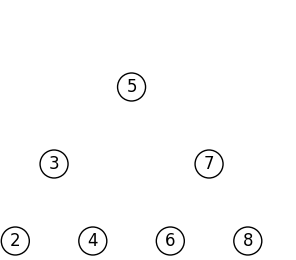

In [17]:
class BSTNode:
    def __init__(self, val=None):
        self.left = None
        self.right = None
        self.val = val

    def insert(self, val):
        if self.val is None:
            self.val = val
            return None
        if val == self.val:
            return None
        if val < self.val:
            if self.left is None:
                self.left = BSTNode(val)
            else:
                self.left.insert(val)
        else:
            if self.right is None:
                self.right = BSTNode(val)
            else:
                self.right.insert(val)

# 테스트 코드
root = BSTNode()
root.insert(5)
root.insert(3)
root.insert(7)
root.insert(2)
root.insert(4)
root.insert(6)
root.insert(8)

# 트리 시각화
import matplotlib.pyplot as plt

def draw_tree(node, x=0, y=0, level=1):
    if node is not None:
        plt.text(x, y, str(node.val), fontsize=12, ha='center', va='center',
                 bbox=dict(facecolor='white', edgecolor='black', boxstyle='circle'))
        draw_tree(node.left, x - 1 / (2 ** level), y - 1, level + 1)
        draw_tree(node.right, x + 1 / (2 ** level), y - 1, level + 1)

plt.figure(figsize=(2, 1))
draw_tree(root)
plt.axis('off')
plt.show()

## 